In [ ]:
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from config_plot import *
from generators import PoissonSpikeGenerator
from stats import ResponseCriteria

from scipy.stats import mannwhitneyu, wilcoxon

1.0


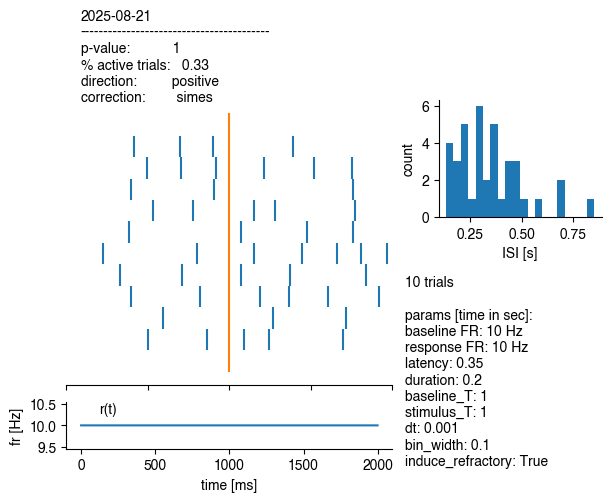

In [58]:
# simulation parameters
baseline_fr  = 10
response_fr  = 10
latency      = 0.350
duration     = 0.2
baseline_T   = 1
stimulus_T   = 1
dt           = 0.001
induce_refractory_period = True

n_trials = 10

# initialize generator with the variables
generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period
)

# generate trials
#trial_activity = generator.generate_trials(n_trials)
trial_activity = generator.generate_numba(n_trials=n_trials)


# analysis parameters
bin_width          = 0.1
proportion_active  = 1/3
direction          = "positive"
multiple_correction = "simes"

# initialize analysis object (using existing trial_activity, baseline_T, stimulus_T)
criteria = ResponseCriteria(
    trial_activity=trial_activity,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    bin_width=bin_width,
    dt=dt,
    proportion_active=proportion_active,
    direction=direction,
    multiple_correction=multiple_correction,
)

print(criteria.compute_pval())


fig, axes = plt.subplot_mosaic(
    [
        ["raster", "isi"],
        ["raster", "text"],
        ["r_t", "text"]
    ], 
    empty_sentinel="empty", 
    width_ratios=[2, 1],
    height_ratios=[1,1,0.4],
    figsize=(6,4),
    layout='constrained',

)

ax = axes["raster"]
ax.eventplot(trial_activity)
ymin, ymax = ax.get_ylim()
ax.vlines(baseline_T, ymin, ymax, colors="tab:orange")
ax.set_xlim(0, baseline_T+stimulus_T)
ax.set_xticklabels([])
ax.set_yticks([])
sns.despine(left=True, ax=ax)

ax = axes["isi"]
isis = np.concatenate([np.diff(t) for t in trial_activity])
ax.hist(isis, bins=20)
sns.despine(ax=ax)
ax.set_xlabel("ISI [s]")
ax.set_ylabel("count")

ax = axes["r_t"]
ax.plot(generator.r_t)
ax.text(
    0.1, 1, "r(t)",
    transform=ax.transAxes,   # use axes coords, not data coords
    ha="left", va="top"      # align text to the top-right
)
ax.set_xlabel("time [ms]")
ax.set_ylabel("fr [Hz]")
sns.despine(ax=ax)

ax = axes["text"]

ax.set_in_layout(False) 
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_anchor('NW')


s = (
    f"{n_trials} trials\n\n"
    f"params [time in sec]:\n"
    f"baseline FR: {baseline_fr} Hz\n"
    f"response FR: {response_fr} Hz\n"
    f"latency: {latency}\n"
    f"duration: {duration}\n"
    f"baseline_T: {baseline_T}\n"
    f"stimulus_T: {stimulus_T}\n"
    f"dt: {dt}\n"
    f"bin_width: {bin_width}\n"
    f"induce_refractory: {induce_refractory_period}"
)

ax.text(
    0.0, 1.0,
    s,
    transform=ax.transAxes,
    ha="left",
    va="top",
    wrap=True
)

ax.set_xticks([])
ax.set_yticks([])

sns.despine(left=True, bottom=True, ax=ax)

s = (
    f"{datetime.today().strftime('%Y-%m-%d')}\n"
    f"-----------------------------------------\n"
    f"p-value:           {criteria.compute_pval():.3g}\n"
    f"% active trials:   {proportion_active:.2f}\n"
    f"direction:         {direction}\n"
    f"correction:        {multiple_correction}"
)
left_ax = axes["raster"]
bbox = left_ax.get_position()
fig.text(
    bbox.x0,        # left edge of subplot
    bbox.y1 + 0.1, # a little above the subplot
    s,
    ha="left",
    va="bottom"
)

plt.show()


In [ ]:
n_units = 100
n_trials = 10

# initialize generator with the variables
generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period
    )

# analysis parameters
bin_width          = 0.1
proportion_active  = 1/3
direction          = "positive"
multiple_correction = "simes"

pval_collection = []

for i in tqdm(range(n_units)):

    trial_activity = generator.generate(n_trials=n_trials)

    # initialize analysis object (using existing trial_activity, baseline_T, stimulus_T)
    criteria = ResponseCriteria(
        trial_activity=trial_activity,
        baseline_T=baseline_T,
        stimulus_T=stimulus_T,
        bin_width=bin_width,
        dt=dt,
        proportion_active=proportion_active,
        direction=direction,
        multiple_correction=multiple_correction,
    )

    pval_collection.append(criteria.compute_pval())

fig, ax = plt.subplots(1,1, figsize=(4,2))

ax.hist(pval_collection, bins=30)
ax.set_xlim(0, 1)
ax.set_xlabel("p-values")
ax.set_ylabel("count")

s = (
    f"{n_trials} trials\n"
    f"{n_units} units\n"
    f"baseline FR: {baseline_fr} Hz\n"
    f"response FR: {response_fr} Hz\n\n"
    f"avg. pvalue: {round(np.mean(pval_collection),3)}"
)

ax.text(
    1.05, 1, s,
    transform=ax.transAxes,   # use axes coords, not data coords
    ha="left", va="top"      # align text to the top-right
)

sns.despine(ax=ax)
plt.savefig(f"plots/{n_trials}trials_{n_units}units_b{baseline_fr}s{response_fr}.png", dpi=100)
plt.show()

  9%|▉         | 9/100 [00:19<03:14,  2.14s/it]